# Urban Safety Risk Forecasting for Morro's Real Estate Investment

## Business Problem
Morro's wants to identify safer neighborhoods in Los Angeles for real estate investments. Crime levels can impact property values, tenant demand, and overall investment risk.

## Business Value
This project will help Morro's:
- Find safer areas to invest in.
- Avoid neighborhoods with rising crime.
- Make data-driven investment decisions.
- Reduce investment risk.

## Business Question
Can historical crime data be used to predict future crime activity in Los Angeles neighborhoods?

## Project Goal
Build a machine learning regression model that predicts the number of crimes expected in a neighborhood during the next month.

## Target Variable
**Crime Count** (Total crimes in a neighborhood during a month)

## Features
- Area Name
- Month
- Year
- Previous Crime Counts
- Crime Categories
- Location Data
- Historical Crime Trends

## Success Criteria
The model should:
- Accurately predict future crime counts.
- Identify neighborhoods with increasing crime trends.
- Identify neighborhoods with decreasing crime trends.
- Provide useful insights for investment decisions.

## Expected Outcome
A forecasting tool that helps Morro's compare neighborhoods and identify safer investment opportunities based on predicted future crime activity.

## One-Sentence Summary
Use historical Los Angeles crime data to predict future neighborhood crime levels and support smarter real estate investment decisions.

In [51]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Date & Time
from datetime import datetime

# Machine Learning
from sklearn.model_selection import train_test_split

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# EDA

In [52]:
import pandas as pd

# Read the crime data CSV
df = pd.read_csv("Crime_Data_from_2020_to_2024.csv")

# Show all column names
df.columns

df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [53]:
df.columns
print(df.columns)

df.describe()
print(df.describe())

df.isnull().sum()
print(df.isnull().sum())


Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')
              DR_NO      TIME OCC          AREA   Rpt Dist No      Part 1-2  \
count  1.004894e+06  1.004894e+06  1.004894e+06  1.004894e+06  1.004894e+06   
mean   2.202190e+08  1.339901e+03  1.069153e+01  1.115613e+03  1.400313e+00   
std    1.319070e+07  6.510761e+02  6.110248e+00  6.111596e+02  4.899620e-01   
min    8.170000e+02  1.000000e+00  1.000000e+00  1.010000e+02  1.000000e+00   
25%    2.106168e+08  9.000000e+02  5.000000e+00  5.870000e+02  1.000000e+00   
50%    2.209158e+08  1.420000e+03  1.100000e+01  1.139000e+03  1.000000e+00   
75%    2.311102e+08  1.900000e+03  1

In [54]:
#Status of the crime
df['Status Desc'].value_counts()

Status Desc
Invest Cont     802772
Adult Other     109799
Adult Arrest     87152
Juv Arrest        3285
Juv Other         1879
UNK                  7
Name: count, dtype: int64

### Date Occ to Year/Month/DOW Feature Engineering 

In [55]:
df['DATE OCC'] = pd.to_datetime(
    df['DATE OCC'],
    format='%m/%d/%Y %I:%M:%S %p'
)

In [56]:
df['Year'] = df['DATE OCC'].dt.year
df['Month'] = df['DATE OCC'].dt.month
df['DayOfWeek'] = df['DATE OCC'].dt.day_name()

df['Hour'] = df['TIME OCC'] // 100

In [57]:
df[['DATE OCC','Year','Month','DayOfWeek','Hour']].head()

,DATE OCC,Year,Month,DayOfWeek,Hour
0,2020-11-07,2020,11,Saturday,8
1,2020-10-18,2020,10,Sunday,18
2,2020-10-30,2020,10,Friday,12
3,2020-12-24,2020,12,Thursday,13
4,2020-09-29,2020,9,Tuesday,18


### Time Analysis 

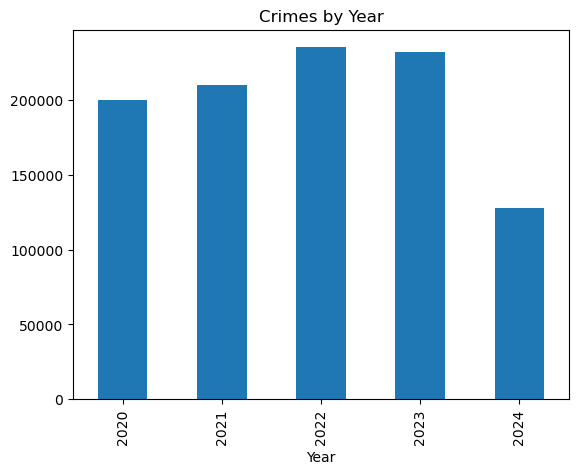

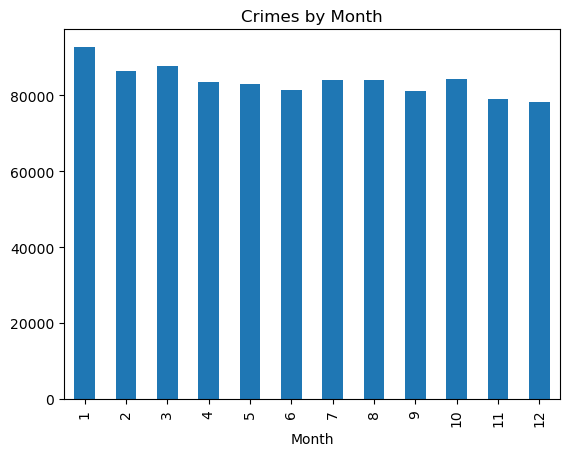

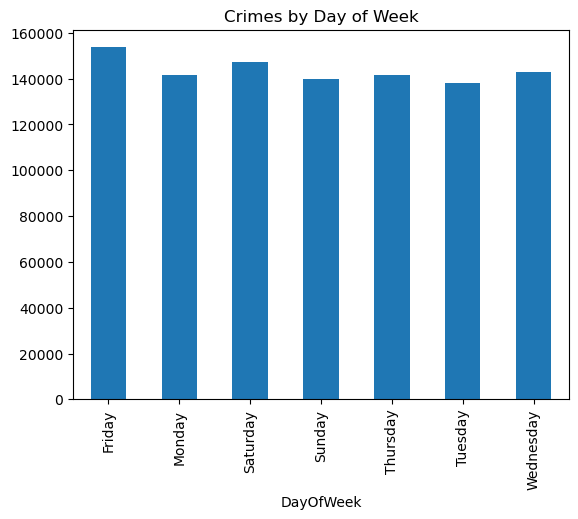

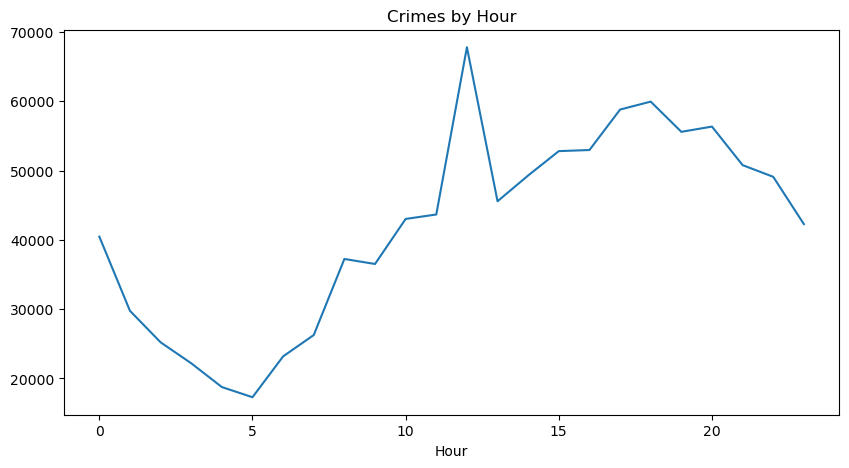

In [58]:


# Crime by Year
df.groupby('Year').size().plot(kind='bar')
plt.title('Crimes by Year')
plt.show()

# Crime by Month
df.groupby('Month').size().plot(kind='bar')
plt.title('Crimes by Month')
plt.show()

# Crime by Day of Week
df.groupby('DayOfWeek').size().plot(kind='bar')
plt.title('Crimes by Day of Week')
plt.show()

# Crime by Hour
df.groupby('Hour').size().plot(figsize=(10,5))
plt.title('Crimes by Hour')
plt.show()

### Crime Distribution Analysis

/var/folders/b1/d60q06cx5s92hfrk5_88lks80000gn/T/ipykernel_96391/2333222827.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


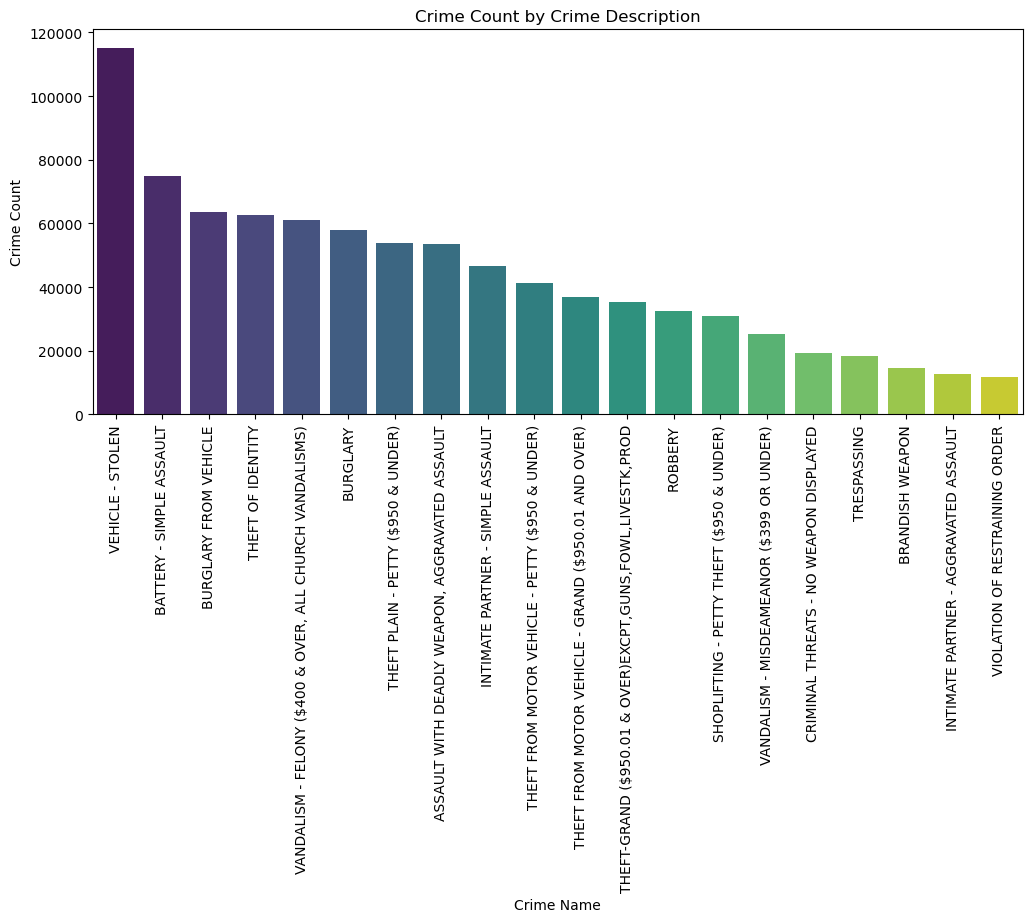

In [59]:
#The most common crimes
df['Crm Cd Desc'].value_counts().head(20)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=df['Crm Cd Desc'].value_counts().head(20).index,
    y=df['Crm Cd Desc'].value_counts().head(20).values,
    palette='viridis'
)
plt.xticks(rotation=90)
plt.title('Crime Count by Crime Description')
plt.xlabel('Crime Name')
plt.ylabel('Crime Count')
plt.show()


### Neighborhood Analysis

/var/folders/b1/d60q06cx5s92hfrk5_88lks80000gn/T/ipykernel_96391/2424414598.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


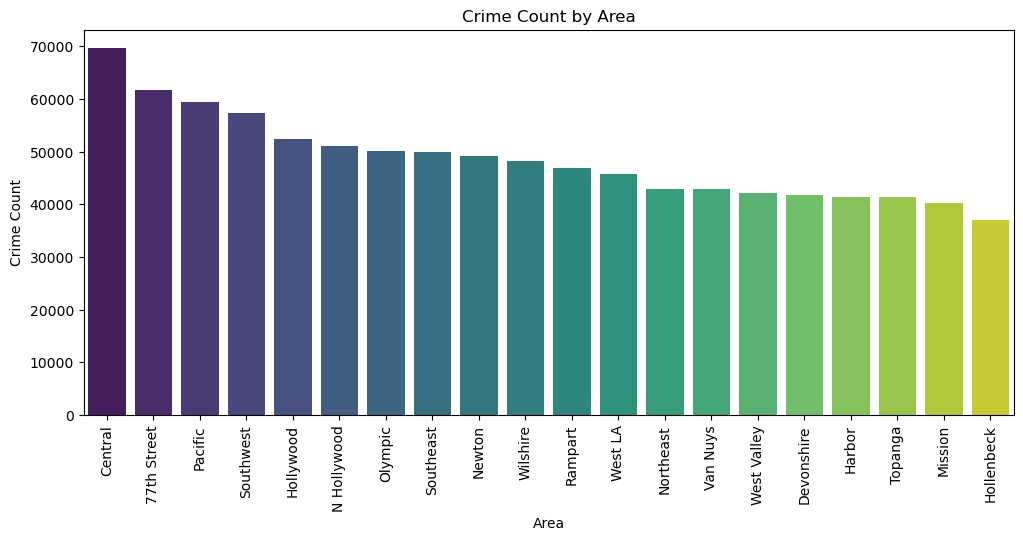

In [60]:
#The most common areas by crime
df['AREA NAME'].value_counts().head(20)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=df['AREA NAME'].value_counts().head(20).index,
    y=df['AREA NAME'].value_counts().head(20).values,
    palette='viridis'
)
plt.xticks(rotation=90)
plt.title('Crime Count by Area')
plt.xlabel('Area')
plt.ylabel('Crime Count')
plt.show()



# Exploratory Data Analysis (EDA) Summary

The exploratory analysis of Los Angeles crime data from 2020 to 2024 was conducted to better understand crime patterns across neighborhoods and identify factors that may help forecast future crime activity.

## Key Findings

### Crime Types
The analysis found that theft-related offenses represent the largest share of reported crimes, with vehicle theft being the most common crime type. This suggests that property-related crimes play a significant role in overall crime activity throughout Los Angeles.

### Neighborhood Crime Activity
Crime levels vary noticeably across neighborhoods. Areas such as Central, 77th Street, and Pacific reported some of the highest crime volumes in the dataset, indicating that location is likely an important factor when evaluating neighborhood safety and investment risk.

### Crime Trends Over Time
Crime activity generally increased between 2020 and 2022 before stabilizing in 2023. While crime counts appear lower in 2024, this is likely due to incomplete data collection for that year rather than a significant reduction in crime.

### Monthly Trends
Crime occurs relatively consistently throughout the year, with only minor differences between months. This suggests that crime activity is not heavily influenced by seasonality at a city-wide level.

### Day of Week Trends
Slightly higher crime activity was observed on Fridays and Saturdays compared to other days of the week. However, crime remains relatively consistent throughout the week overall.

### Time of Day Trends
Crime incidents were least common during the early morning hours and became more frequent throughout the day. Crime activity peaked during midday and evening hours, indicating that time of day may be an important predictor of future crime levels.

## Conclusion

Overall, the analysis suggests that both location and time-related factors influence crime activity across Los Angeles neighborhoods. These findings support the development of a predictive model that forecasts future neighborhood crime levels and helps Morro's Real Estate Investment Firm identify safer, lower-risk investment opportunities.

# Data Preprocessing and Feature Engineering


In [61]:
#rename columns for better readability
df = df.rename(columns={
    'DR_NO': 'dr_no',
    'Date Rptd': 'date_reported',
    'DATE OCC': 'date_occurred',
    'TIME OCC': 'time_occurred',
    'AREA': 'area_code',
    'AREA NAME': 'area_name',
    'Rpt Dist No': 'report_district',
    'Part 1-2': 'crime_part',
    'Crm Cd': 'crime_code',
    'Crm Cd Desc': 'crime_description',
    'Mocodes': 'mo_codes',
    'Vict Age': 'victim_age',
    'Vict Sex': 'victim_sex',
    'Vict Descent': 'victim_descent',
    'Premis Cd': 'premise_code',
    'Premis Desc': 'premise_description',
    'Weapon Used Cd': 'weapon_code',
    'Weapon Desc': 'weapon_description',
    'Status': 'status_code',
    'Status Desc': 'status_description',
    'Crm Cd 1': 'primary_crime_code',
    'Crm Cd 2': 'secondary_crime_code',
    'Crm Cd 3': 'third_crime_code',
    'Crm Cd 4': 'fourth_crime_code',
    'LOCATION': 'location',
    'Cross Street': 'cross_street',
    'LAT': 'latitude',
    'LON': 'longitude'
})

In [62]:
#verify the new column names
df.columns

Index(['dr_no', 'date_reported', 'date_occurred', 'time_occurred', 'area_code',
       'area_name', 'report_district', 'crime_part', 'crime_code',
       'crime_description', 'mo_codes', 'victim_age', 'victim_sex',
       'victim_descent', 'premise_code', 'premise_description', 'weapon_code',
       'weapon_description', 'status_code', 'status_description',
       'primary_crime_code', 'secondary_crime_code', 'third_crime_code',
       'fourth_crime_code', 'location', 'cross_street', 'latitude',
       'longitude', 'Year', 'Month', 'DayOfWeek', 'Hour'],
      dtype='object')

In [63]:
#drop columns that are not needed   
df = df.drop(columns=[
    'dr_no',
    'location',
    'cross_street',
    'secondary_crime_code',
    'third_crime_code',
    'fourth_crime_code',
    'status_code',
    'status_description'
])

print(df.shape)


(1004894, 24)


In [64]:
df.columns
# Check number of duplicate rows
df.duplicated().sum()

# Check for missing values
df.isnull().sum()




date_reported               0
date_occurred               0
time_occurred               0
area_code                   0
area_name                   0
report_district             0
crime_part                  0
crime_code                  0
crime_description           0
mo_codes               151598
victim_age                  0
victim_sex             144631
victim_descent         144643
premise_code               16
premise_description       588
weapon_code            677678
weapon_description     677678
primary_crime_code         11
latitude                    0
longitude                   0
Year                        0
Month                       0
DayOfWeek                   0
Hour                        0
dtype: int64

In [65]:
# Remove duplicates
df = df.drop_duplicates()

# Verify removal
df.duplicated().sum()

np.int64(0)

In [66]:
#missing values by percentage
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percent Missing': round(df.isnull().mean() * 100, 2)
})

missing.sort_values('Percent Missing', ascending=False)

,Missing Values,Percent Missing
weapon_description,675502,67.43
weapon_code,675502,67.43
mo_codes,150242,15.00
victim_descent,143327,14.31
victim_sex,143315,14.31
premise_description,587,0.06
premise_code,16,0.00
DayOfWeek,0,0.00
Month,0,0.00
Year,0,0.00


In [67]:
#drop extra columns that are not needed
df = df.drop(columns=[
    'weapon_code',
    'weapon_description',
    'mo_codes',
    'victim_sex',
    'victim_descent'
])

In [68]:
df['date_occurred'].head()

0   2020-11-07
1   2020-10-18
2   2020-10-30
3   2020-12-24
4   2020-09-29
Name: date_occurred, dtype: datetime64[ns]

In [69]:
df[['date_occurred', 'Year', 'Month', 'DayOfWeek', 'Hour']].head()

,date_occurred,Year,Month,DayOfWeek,Hour
0,2020-11-07,2020,11,Saturday,8
1,2020-10-18,2020,10,Sunday,18
2,2020-10-30,2020,10,Friday,12
3,2020-12-24,2020,12,Thursday,13
4,2020-09-29,2020,9,Tuesday,18


In [70]:
#rename columns for consistency
df = df.rename(columns={
    'Year': 'year',
    'Month': 'month',
    'DayOfWeek': 'day_of_week',
    'Hour': 'hour'
})

### Preproccessing Complete
#### The preprocessing stage included checking for duplicate records, identifying missing values, and converting date fields into a usable datetime format. Additional time-based features such as year, month, day of week, and hour were extracted from the crime occurrence date. These features will support future analysis and help capture temporal crime patterns that may improve forecasting performance.

### Feature Engineering

In [71]:
#create a monthly crime count dataframe
monthly_crime = (
    df.groupby(['area_name', 'year', 'month'])
      .size()
      .reset_index(name='crime_count')
)

In [72]:
#previous crime count
monthly_crime = monthly_crime.sort_values(
    ['area_name', 'year', 'month']
)

monthly_crime['previous_crime_count'] = (
    monthly_crime.groupby('area_name')['crime_count']
                 .shift(1)
)

In [73]:
#create rolling average 
monthly_crime['rolling_average'] = (
    monthly_crime.groupby('area_name')['crime_count']
                 .transform(
                     lambda x: x.shift(1)
                               .rolling(window=3)
                               .mean()
                 )
)

In [74]:
#crime trend
monthly_crime['crime_trend'] = (
    monthly_crime['crime_count']
    - monthly_crime['previous_crime_count']
)

In [75]:
#check the new columns
monthly_crime.head(50)

,area_name,year,month,crime_count,previous_crime_count,rolling_average,crime_trend
0,77th Street,2020,1,1305,NaN,NaN,NaN
1,77th Street,2020,2,1103,1305.0,NaN,-202.0
2,77th Street,2020,3,1012,1103.0,NaN,-91.0
3,77th Street,2020,4,1064,1012.0,1140.000000,52.0
4,77th Street,2020,5,1074,1064.0,1059.666667,10.0
5,77th Street,2020,6,1098,1074.0,1050.000000,24.0
6,77th Street,2020,7,1103,1098.0,1078.666667,5.0
7,77th Street,2020,8,1232,1103.0,1091.666667,129.0
8,77th Street,2020,9,1070,1232.0,1144.333333,-162.0
9,77th Street,2020,10,1152,1070.0,1135.000000,82.0


### Engineered Features

### Crime Count (`crime_count`)
The `crime_count` feature measures the total number of crimes occurring in a neighborhood during a given month. This serves as the target variable for the forecasting model and represents the value the model is trying to predict.

### Previous Crime Count (`previous_crime_count`)
The `previous_crime_count` feature captures the number of crimes that occurred in the neighborhood during the previous month. This provides historical context and helps the model learn patterns from recent crime activity.

### Rolling Average (`rolling_average`)
The `rolling_average` feature calculates the average crime count over the previous three months. This helps smooth short-term fluctuations and allows the model to recognize longer-term crime patterns and trends.

### Crime Trend (`crime_trend`)
The `crime_trend` feature measures the month-to-month change in crime activity by comparing the current month's crime count to the previous month's crime count. This helps the model identify whether crime levels are increasing, decreasing, or remaining stable over time.

## Model Development

##### Data Preparation

In [76]:
# Train on historical years
train_data = monthly_crime_model[
    monthly_crime_model['year'] < 2024
]

# Test on future year
test_data = monthly_crime_model[
    monthly_crime_model['year'] == 2024
]

# Features and target
X_train = train_data.drop('crime_count', axis=1)
y_train = train_data['crime_count']

X_test = test_data.drop('crime_count', axis=1)
y_test = test_data['crime_count']

print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

Training Rows: 945
Testing Rows: 252


In [77]:
# Remove rows with lag/rolling NaNs
#monthly_crime_model = monthly_crime.dropna().copy()

# Features and target
#X = monthly_crime_model.drop('crime_count', axis=1)
#y = monthly_crime_model['crime_count']

# Train/Test Split
#X_train, X_test, y_train, y_test = train_test_split(
   # X,
    #y,
    #test_size=0.2,
    #random_state=42
#)

# Feature groups
#numeric_features = [
 #   'year',
    #'month',
   # 'previous_crime_count',
   # 'rolling_average',
   
#]

#categorical_features = [
   # 'area_name'
#]

In [78]:
# Numeric preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

##Baseline Models
# Linear Regression Pipeline
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train models
linear_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [79]:
# Predictions
linear_preds = linear_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

# Evaluation function
def evaluate_model(model_name, y_true, predictions):

    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

# Store results
results = [
    evaluate_model(
        'Linear Regression',
        y_test,
        linear_preds
    ),
    evaluate_model(
        'Random Forest Regressor',
        y_test,
        rf_preds
    )
]

# Results table
results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,195.862328,52924.917051,230.054161,0.191706
1,Random Forest Regressor,214.834325,63121.221020,251.239370,0.035984


In [81]:
from xgboost import XGBRegressor

# XGBoost Pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

# Train XGBoost model
xgb_pipeline.fit(X_train, y_train)

# Make predictions
xgb_preds = xgb_pipeline.predict(X_test)

# Add XGBoost results
results.append(
    evaluate_model(
        'XGBoost Regressor',
        y_test,
        xgb_preds
    )
)

# Updated results table
results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,195.862328,52924.917051,230.054161,0.191706
1,Random Forest Regressor,214.834325,63121.221020,251.239370,0.035984
2,XGBoost Regressor,245.999741,82280.367188,286.845546,-0.256623


In [88]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np
import pandas as pd

tscv = TimeSeriesSplit(n_splits=5)

models = {
    'Linear Regression': linear_pipeline,
    'Random Forest Regressor': rf_pipeline,
    'XGBoost Regressor': xgb_pipeline
}

cv_results = []

for model_name, model_pipeline in models.items():

    r2_scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=tscv,
        scoring='r2'
    )

    neg_mse_scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=tscv,
        scoring='neg_mean_squared_error'
    )

    rmse_scores = np.sqrt(-neg_mse_scores)

    cv_results.append({
        'Model': model_name,
        'CV R2 Scores': r2_scores,
        'Mean CV R2': r2_scores.mean(),
        'Std CV R2': r2_scores.std(),
        'CV RMSE Scores': rmse_scores,
        'Mean CV RMSE': rmse_scores.mean(),
        'Std CV RMSE': rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,CV R2 Scores,Mean CV R2,Std CV R2,CV RMSE Scores,Mean CV RMSE,Std CV RMSE
0,Linear Regression,"[0.7752515070682029, 0.7417056541414613, 0.741...",0.731843,0.068452,"[69.97365962654354, 63.402198143235104, 65.616...",65.522465,3.096560
1,Random Forest Regressor,"[0.7400952724835076, 0.7142331661868215, 0.682...",0.703068,0.081464,"[75.24770929496876, 66.68878066243256, 72.7160...",68.705840,4.473068
2,XGBoost Regressor,"[0.7517303228378296, 0.6892707943916321, 0.677...",0.711057,0.070918,"[73.54413468179328, 69.54051202356796, 73.2309...",67.982090,5.342566


In [91]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# -----------------------------
# RIDGE REGRESSION
# -----------------------------
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_search = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

# -----------------------------
# RANDOM FOREST
# -----------------------------
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_search = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

# -----------------------------
# XGBOOST
# -----------------------------
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

xgb_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

xgb_search = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

# -----------------------------
# BEST MODELS
# -----------------------------
print("Best Ridge Parameters:")
print(ridge_search.best_params_)
print("Best Ridge CV R²:", ridge_search.best_score_)

print("\nBest Random Forest Parameters:")
print(rf_search.best_params_)
print("Best Random Forest CV R²:", rf_search.best_score_)

print("\nBest XGBoost Parameters:")
print(xgb_search.best_params_)
print("Best XGBoost CV R²:", xgb_search.best_score_)

# -----------------------------
# TEST SET EVALUATION (2024)
# -----------------------------
best_models = {
    "Ridge Regression": ridge_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_
}

results = []

for name, model in best_models.items():
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    })

tuned_results_df = pd.DataFrame(results)
tuned_results_df

Best Ridge Parameters:
{'model__alpha': 10}
Best Ridge CV R²: 0.7394834970545342

Best Random Forest Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best Random Forest CV R²: 0.7144950742822711

Best XGBoost Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best XGBoost CV R²: 0.757567310333252


,Model,MAE,MSE,RMSE,R2
0,Ridge Regression,153.546052,36546.013846,191.170118,0.441853
1,Random Forest,215.242677,62806.541640,250.612333,0.040790
2,XGBoost,226.604019,70696.093750,265.887370,-0.079703


- Hyperparameter tuning identified Ridge Regression as the best-performing model. Ridge achieved a cross-validation R² of approximately 0.74 and a holdout-year R² of 0.44 when forecasting 2024 crime counts. While more complex models such as Random Forest and XGBoost performed well during cross-validation, their performance deteriorated substantially on the unseen 2024 data, suggesting overfitting. Ridge Regression provided the strongest balance between predictive accuracy and generalization.

In [ ]:
import numpy as np
#from sklearn.model_selection import cross_val_score
#i#mport pandas as pd

#models = {
# Store pipelines in a dictionary
    #'Linear Regression': linear_pipeline,
   # 'Random Forest Regressor': rf_pipeline,
   # 'XGBoost Regressor': xgb_pipeline
#}

# Run 5-fold cross-validation
#cv_results = []

#for model_name, model_pipeline in models.items():
    
    #scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='r2'
    #)
    
    #cv_results.append({
        'Model': model_name,
        'CV R2 Scores': scores,
        'Mean CV R2': scores.mean(),
        'Std CV R2': scores.std()
    #})

# Convert to DataFrame
#c#v_results_df = pd.DataFrame(cv_results)

#cv_results_df